# Exploratory Data Analysis for RAG Response Reliability

This notebook performs a reproducible exploratory analysis of the processed RAG reliability dataset.

## Goals

1. Load the train, validation, and test splits.
2. Inspect schema, missing values, and duplicates.
3. Detect the question, answer, context, and label columns.
4. Analyze Faithfulness, Relevancy, and Reliability labels.
5. Verify whether `Reliability = Faithfulness AND Relevancy`.
6. Analyze text lengths.
7. Check overlap between dataset splits.
8. Inspect representative error cases.
9. Save compact EDA reports under `results/data_exploration/`.

> Run the notebook from top to bottom.  
> If automatic column detection selects the wrong fields, edit the `MANUAL_COLUMNS` dictionary in Section 3.


## 1. Imports and display settings

In [1]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 300)

RANDOM_STATE = 42


## 2. Locate the project and load all processed splits

In [2]:
def find_project_root(start: Path) -> Path:
    """Find a parent directory containing the processed dataset directory."""
    start = start.resolve()

    candidates = [start, *start.parents]

    for candidate in candidates:
        if (candidate / "processed").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not find a project root containing a 'processed' directory. "
        "Save this notebook inside the repository and try again."
    )


ROOT_DIR = find_project_root(Path.cwd())
PROCESSED_DIR = ROOT_DIR / "processed"
RESULTS_DIR = ROOT_DIR / "results" / "data_exploration"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_PATHS = {
    "train": PROCESSED_DIR / "train.csv",
    "validation": PROCESSED_DIR / "val.csv",
    "test": PROCESSED_DIR / "test.csv",
}

print("Project root:", ROOT_DIR)
print("Processed data:", PROCESSED_DIR)
print("EDA output:", RESULTS_DIR)


Project root: /Users/chengyi/assessing-reliability-of-responses-in-rag
Processed data: /Users/chengyi/assessing-reliability-of-responses-in-rag/processed
EDA output: /Users/chengyi/assessing-reliability-of-responses-in-rag/results/data_exploration


In [3]:
datasets = {}

for split_name, file_path in SPLIT_PATHS.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Missing required file: {file_path}")

    df = pd.read_csv(file_path, low_memory=False)
    datasets[split_name] = df

    print(
        f"{split_name:>10}: "
        f"{len(df):,} rows × {len(df.columns)} columns"
    )

train_df = datasets["train"]
validation_df = datasets["validation"]
test_df = datasets["test"]

display(train_df.head(3))


     train: 1,450 rows × 28 columns
validation: 290 rows × 28 columns
      test: 290 rows × 28 columns


,source_row,full_dialog,answer,chunk_1,chunk_2,chunk_3,chunk_4,chunk_5,chunk_6,chunk_7,chunk_8,binary_relevancy,binary_faithfulness,markers,source_csv_row,binary_reliability,chunk_count,retrieval_config,has_marker,mask_count,question,has_question,input_hash,dialog_group_id,case_id,joint_label,fold,split
0,1,"Ассистент: Приветствую, [NAME]! На связи Альфа-Помощник 🦸‍♂️Кэшбэк за июль начислим 10 августа до конца дня.\n\n📲 Проверить поступление и обменять кэшбэк можно в разделе [Кэшбэк и сервисы.]([URL]\n\n[Ответы на популярные вопросы о кэшбэке.]([URL]\nКлиент: Выключить все комиссии\nАссистент: Что х...","Чтобы отключить комиссию за новый Альфа-Чек, подайте обращение через мобильное приложение: откройте историю операций, найдите транзакцию с комиссией и выберите «Оспорить». Для отмены других комиссий проверьте наличие льготных счетов (экспресс-счёт, кредитная карта и др.) — тогда списание может б...",Название статьи: Подача обращений из «Истории операций» в приложении Альфа-Банка\n\n\nСсылка: [URL]\n\n\nСодержание: # Подача обращений из «Истории операций» в приложении Альфа-Банка\n## 4. Процесс оспаривания комиссии\n**Ограничения по комиссиям:** \n1. Оспаривать можно комиссии за последние 1...,Название статьи: Подача обращений из истории операций в Альфа-Онлайн\n\n\nСсылка: [URL]\n\n\nСодержание: # Подача обращений из истории операций в Альфа-Онлайн\n## 4. Оспаривание комиссии\n**Ограничения по комиссиям:** \n1. Оспаривать можно комиссии за последние 12 месяцев (холды не оспариваются...,"Название статьи: Приложение Альфа-Банка\n\n\nСсылка: [URL]\n\n\nСодержание: # Приложение Альфа-Банка\n## Тарифы\n### Стоимость\n[Тарифы по пакетам услуг]( и УЛК \n**Комиссию не списываем** у клиентов, у которых нет текущего счёта, но открыты: \n* экспресс-счёт, Мой сейф НТ, Улётный, АэроПлан, ...",Название статьи: Подписка на услугу Уведомления об операциях\n\n\nСсылка: [URL]\n\n\nСодержание: # Подписка на услугу Уведомления об операциях\n## Как воспользоваться\n### Как отключить\nОтключить подписки можно в: \n* **Приложении Альфа-Банка**. Для этого на экране с тарифами подписки нужно вы...,Название статьи: Пакет услуг Alfa Only (ранее Премиум)\n\n\nСсылка: [URL]\n\n\nСодержание: # Пакет услуг Alfa Only (ранее Премиум)\n## Преимущества\n### Преимущества\n3 апреля [NUMBER] года отменили комиссию за переводы на\nпакете услуг Alfa Only. \n**Комиссию не списываем при:** \n* Переводах...,NaN,NaN,NaN,False,False,NaN,3,0,5,top_5,False,16,Комиссию за предоставление услуг в альфа чек,True,input_2416766a973c57f76543,dialog_58ef3075c07a797f459a,case_2416766a973c57f76543,0_0,6,train
1,2,"Ассистент: Приветствую, [NAME]! На связи Альфа-Помощник 🦸‍♂️Собрали ответы на частые [вопросы о дебетовых картах]([URL] и [кредитках.]([URL]\nКлиент: Почему в истории платежей не отобразился платеж за ростовводоканал?",Платеж за Ростовводоканал мог не отобразиться по одной из причин: 1) операция была проведена по закрытому счету (их мы не показываем); 2) время платежа попало в период с [DATE][DATE] — в таком случае дата может быть указана как предыдущего дня; 3) платеж старше 13 месяцев (история хранится тольк...,Название статьи: История операций в приложении Альфа-Банка\n\n\nСсылка: [URL]\n\n\nСодержание: # История операций в приложении Альфа-Банка\n## 6. Экспорт истории операций в xls\n| | | |\n| --- | --- | --- |\n| 1. Клиент заходит в экспорт истории с экрана истории операций. | 2. Для скачивания нуж...,"Название статьи: История операций в приложении Альфа-Банка\n\n\nСсылка: [URL]\n\n\nСодержание: # История операций в приложении Альфа-Банка\n## 1. История операций\nОперации по закрытым счетам (в том числе депозитам, кредитам и так далее, если соответствующий счёт закрыт) в истории операций **не ...","Название статьи: История операций в Альфа-Онлайн\n\n\nСсылка: [URL]\n\n\nСодержание: # История операций в Альфа-Онлайн\n## 1. История операций\nОперации по закрытым счетам (в том числе депозитам, кредитам и так далее, если соответствующий счёт закрыт) в истории операций **

## 3. Inspect the schema and detect important columns

In [4]:
schema_summary = pd.DataFrame({
    "column": train_df.columns,
    "dtype": train_df.dtypes.astype(str).values,
    "non_null_count": train_df.notna().sum().values,
    "missing_count": train_df.isna().sum().values,
    "missing_ratio": train_df.isna().mean().values,
    "unique_count": train_df.nunique(dropna=False).values,
})

display(schema_summary)
print("\nColumn names:")
for index, column in enumerate(train_df.columns, start=1):
    print(f"{index:>2}. {column}")


,column,dtype,non_null_count,missing_count,missing_ratio,unique_count
0,source_row,int64,1450,0,0.000000,1450
1,full_dialog,str,1450,0,0.000000,1385
2,answer,str,1450,0,0.000000,1448
3,chunk_1,str,1450,0,0.000000,746
4,chunk_2,str,1450,0,0.000000,848
5,chunk_3,str,1450,0,0.000000,929
6,chunk_4,str,1450,0,0.000000,937
7,chunk_5,str,1450,0,0.000000,969
8,chunk_6,str,256,1194,0.823448,249
9,chunk_7,str,256,1194,0.823448,247



Column names:
 1. source_row
 2. full_dialog
 3. answer
 4. chunk_1
 5. chunk_2
 6. chunk_3
 7. chunk_4
 8. chunk_5
 9. chunk_6
10. chunk_7
11. chunk_8
12. binary_relevancy
13. binary_faithfulness
14. markers
15. source_csv_row
16. binary_reliability
17. chunk_count
18. retrieval_config
19. has_marker
20. mask_count
21. question
22. has_question
23. input_hash
24. dialog_group_id
25. case_id
26. joint_label
27. fold
28. split


In [5]:
# Edit only this dictionary if automatic detection chooses the wrong column.
# Keep a value as None to use automatic detection.

MANUAL_COLUMNS = {
    "question": None,
    "answer": None,
    "context": "chunk_1",  # primary chunk; full context built via build_combined_context() below
    "faithfulness": None,
    "relevancy": None,
    "reliability": None,
    "identifier": None,
}


CHUNK_COLUMNS = ["chunk_1", "chunk_2", "chunk_3", "chunk_4", "chunk_5"]


def build_combined_context(df: pd.DataFrame) -> pd.Series:
    """Concatenate all available chunk columns into a single context string.

    The processed dataset stores retrieved chunks as separate columns (chunk_1…chunk_5;
    chunk_6…chunk_8 may also be present for top-8 retrieval).  This helper safely joins
    all present chunk columns into one string per row so that text-length analysis and
    cross-split overlap checking can work on the complete context.

    Returns a Series of strings (NaN becomes an empty string).
    """
    available = [c for c in CHUNK_COLUMNS if c in df.columns]
    if not available:
        return pd.Series(dtype=str)
    joined = df[available].fillna("").astype(str).agg("\n\n".join, axis=1)
    return joined.str.strip()

COLUMN_ALIASES = {
    "question": [
        "question", "query", "user_query", "user_question",
        "prompt", "request", "user_message", "message"
    ],
    "answer": [
        "answer", "response", "generated_answer",
        "generated_response", "assistant_answer", "assistant_response"
    ],
    "context": [
        "context", "contexts", "retrieved_context",
        "retrieved_contexts", "retrieved_chunks", "chunks",
        "documents", "source_documents", "knowledge"
    ],
    "faithfulness": [
        "faithfulness", "faithful", "groundedness",
        "grounded", "is_faithful"
    ],
    "relevancy": [
        "relevancy", "relevance", "relevant",
        "answer_relevancy", "is_relevant"
    ],
    "reliability": [
        "reliability", "reliable", "joint_reliability",
        "joint_label", "is_reliable"
    ],
    "identifier": [
        "id", "sample_id", "row_id", "conversation_id",
        "dialog_id", "chat_id", "request_id"
    ],
}


def normalize_column_name(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", str(name).lower()).strip("_")


def detect_column(columns, aliases):
    """Prefer exact normalized matches, then controlled substring matches."""
    normalized_map = {
        normalize_column_name(column): column
        for column in columns
    }

    for alias in aliases:
        normalized_alias = normalize_column_name(alias)
        if normalized_alias in normalized_map:
            return normalized_map[normalized_alias]

    for alias in aliases:
        normalized_alias = normalize_column_name(alias)
        matches = [
            original
            for normalized, original in normalized_map.items()
            if normalized_alias in normalized
        ]
        if len(matches) == 1:
            return matches[0]

    return None


SELECTED_COLUMNS = {}

for role, aliases in COLUMN_ALIASES.items():
    manual_value = MANUAL_COLUMNS.get(role)

    if manual_value is not None:
        if manual_value not in train_df.columns:
            raise KeyError(
                f"Manual column '{manual_value}' for role '{role}' "
                "does not exist in the training data."
            )
        SELECTED_COLUMNS[role] = manual_value
    else:
        SELECTED_COLUMNS[role] = detect_column(train_df.columns, aliases)

selected_columns_table = pd.DataFrame(
    [
        {"role": role, "selected_column": column}
        for role, column in SELECTED_COLUMNS.items()
    ]
)

display(selected_columns_table)

unresolved_roles = [
    role for role, column in SELECTED_COLUMNS.items()
    if column is None
]

if unresolved_roles:
    print(
        "Unresolved roles:",
        unresolved_roles,
        "\nThis is not always an error. Edit MANUAL_COLUMNS only when needed."
    )


,role,selected_column
0,question,question
1,answer,answer
2,context,chunk_1
3,faithfulness,binary_faithfulness
4,relevancy,binary_relevancy
5,reliability,joint_label
6,identifier,NaN


Unresolved roles: ['identifier'] 
This is not always an error. Edit MANUAL_COLUMNS only when needed.


## 4. Dataset size, missing values, and duplicates

In [6]:
split_summary_records = []

for split_name, df in datasets.items():
    split_summary_records.append({
        "split": split_name,
        "rows": len(df),
        "columns": len(df.columns),
        "exact_duplicate_rows": int(df.duplicated().sum()),
        "exact_duplicate_ratio": float(df.duplicated().mean()),
    })

split_summary = pd.DataFrame(split_summary_records)
display(split_summary)

split_summary.to_csv(
    RESULTS_DIR / "split_overview.csv",
    index=False,
)


,split,rows,columns,exact_duplicate_rows,exact_duplicate_ratio
0,train,1450,28,0,0.0
1,validation,290,28,0,0.0
2,test,290,28,0,0.0


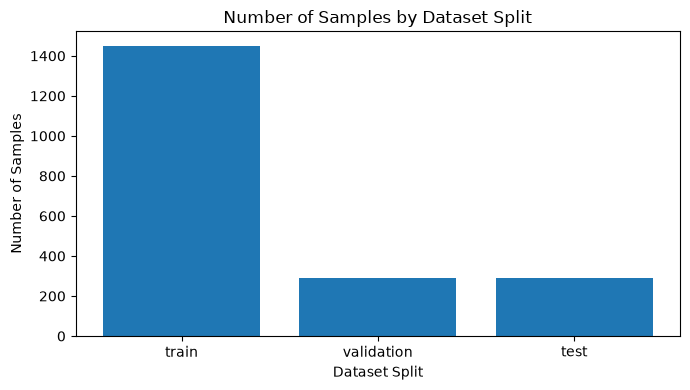

In [7]:
plt.figure(figsize=(7, 4))
plt.bar(split_summary["split"], split_summary["rows"])
plt.title("Number of Samples by Dataset Split")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()


In [8]:
missing_reports = []

for split_name, df in datasets.items():
    report = pd.DataFrame({
        "split": split_name,
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_ratio": df.isna().mean().values,
    })
    missing_reports.append(report)

missing_report = pd.concat(missing_reports, ignore_index=True)
missing_report = missing_report.sort_values(
    ["missing_ratio", "missing_count"],
    ascending=False,
)

display(missing_report[missing_report["missing_count"] > 0].head(50))

missing_report.to_csv(
    RESULTS_DIR / "missing_values.csv",
    index=False,
)


,split,column,missing_count,missing_ratio
69,test,markers,276,0.951724
13,train,markers,1361,0.938621
41,validation,markers,271,0.934483
64,test,chunk_6,239,0.824138
65,test,chunk_7,239,0.824138
66,test,chunk_8,239,0.824138
8,train,chunk_6,1194,0.823448
9,train,chunk_7,1194,0.823448
10,train,chunk_8,1194,0.823448
36,validation,chunk_6,237,0.817241


## 5. Normalize and analyze label columns

In [9]:
def normalize_binary_label(series: pd.Series) -> pd.Series:
    """Convert common binary label formats to pandas nullable integers.

    Note: This function does NOT handle joint labels like "0_1", "1_0", etc.
    Use normalize_reliability_label() for joint_label columns instead.
    """
    truthy = {
        "1", "true", "yes", "y", "positive",
        "faithful", "relevant", "reliable", "supported"
    }
    falsy = {
        "0", "false", "no", "n", "negative",
        "unfaithful", "irrelevant", "unreliable", "unsupported"
    }

    def convert(value):
        if pd.isna(value):
            return pd.NA

        if isinstance(value, (bool, np.bool_)):
            return int(value)

        if isinstance(value, (int, np.integer)):
            return int(value) if value in (0, 1) else pd.NA

        if isinstance(value, (float, np.floating)):
            if value in (0.0, 1.0):
                return int(value)
            return pd.NA

        normalized = str(value).strip().lower()

        if normalized in truthy:
            return 1
        if normalized in falsy:
            return 0

        # Explicitly reject strings with underscores to prevent
        # mis-parsing of joint labels like "0_1" as numeric 0 or 1.
        if "_" in normalized:
            return pd.NA

        try:
            numeric = float(normalized)
            if numeric in (0.0, 1.0):
                return int(numeric)
        except ValueError:
            pass

        return pd.NA

    return series.map(convert).astype("Int64")


def normalize_reliability_label(series: pd.Series) -> pd.Series:
    """Normalize joint labels for reliability = (relevancy AND faithfulness).

    joint_label format: {relevancy}_{faithfulness}
    Examples:
        - "1_1" -> 1  (reliable: both relevancy and faithfulness are true)
        - "0_0" -> 0  (unreliable: both are false)
        - "0_1" -> 0  (unreliable: relevancy is false)
        - "1_0" -> 0  (unreliable: faithfulness is false)

    Returns a pandas nullable integer series (0, 1, or NA).
    """
    RELIABILITY_MAPPING = {
        "1_1": 1,  # reliable: relevancy=1 AND faithfulness=1
        "0_0": 0,  # unreliable: relevancy=0 AND faithfulness=0
        "0_1": 0,  # unreliable: relevancy=0
        "1_0": 0,  # unreliable: faithfulness=0
    }

    def convert(value):
        if pd.isna(value):
            return pd.NA

        normalized = str(value).strip()
        return RELIABILITY_MAPPING.get(normalized, pd.NA)

    return series.map(convert).astype("Int64")


LABEL_ROLES = ["faithfulness", "relevancy"]
NORMALIZED_LABEL_COLUMNS = {}

for split_name, df in datasets.items():
    for role in LABEL_ROLES:
        source_column = SELECTED_COLUMNS.get(role)

        if source_column is None or source_column not in df.columns:
            continue

        normalized_column = f"__{role}_binary"
        df[normalized_column] = normalize_binary_label(df[source_column])
        NORMALIZED_LABEL_COLUMNS[role] = normalized_column

# Handle reliability separately using joint_label with explicit mapping
reliability_role = "reliability"
reliability_source = SELECTED_COLUMNS.get(reliability_role)
if reliability_source:
    for split_name, df in datasets.items():
        if reliability_source in df.columns:
            normalized_column = f"__{reliability_role}_binary"
            df[normalized_column] = normalize_reliability_label(df[reliability_source])
            NORMALIZED_LABEL_COLUMNS[reliability_role] = normalized_column

print("Normalized label columns:", NORMALIZED_LABEL_COLUMNS)


Normalized label columns: {'faithfulness': '__faithfulness_binary', 'relevancy': '__relevancy_binary', 'reliability': '__reliability_binary'}


In [10]:
label_distribution_records = []

for split_name, df in datasets.items():
    for role, normalized_column in NORMALIZED_LABEL_COLUMNS.items():
        counts = df[normalized_column].value_counts(dropna=False)

        for label_value, count in counts.items():
            label_distribution_records.append({
                "split": split_name,
                "label": role,
                "value": str(label_value),
                "count": int(count),
                "ratio": float(count / len(df)),
            })

label_distribution = pd.DataFrame(label_distribution_records)
display(label_distribution)

label_distribution.to_csv(
    RESULTS_DIR / "label_distribution.csv",
    index=False,
)


,split,label,value,count,ratio
0,train,faithfulness,1,1059,0.730345
1,train,faithfulness,0,391,0.269655
2,train,relevancy,1,1267,0.873793
3,train,relevancy,0,183,0.126207
4,train,reliability,1,1042,0.718621
5,train,reliability,0,408,0.281379
6,validation,faithfulness,1,213,0.734483
7,validation,faithfulness,0,77,0.265517
8,validation,relevancy,1,253,0.872414
9,validation,relevancy,0,37,0.127586


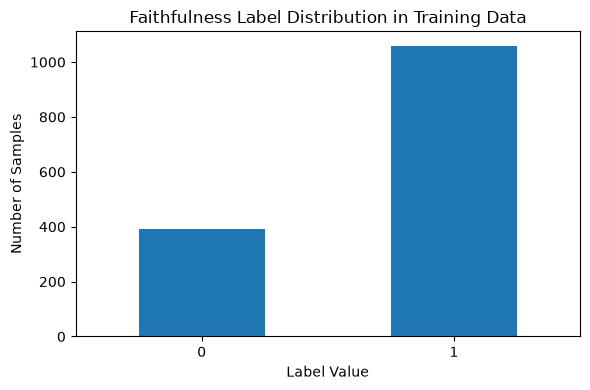

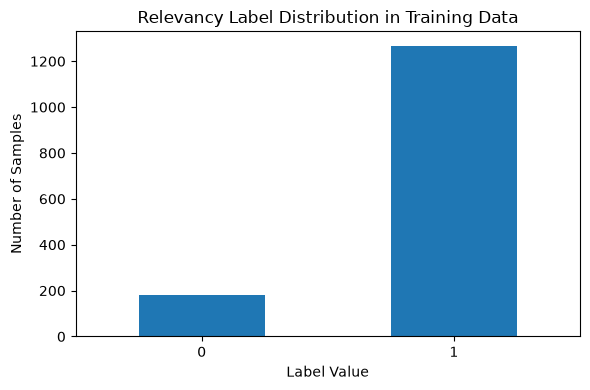

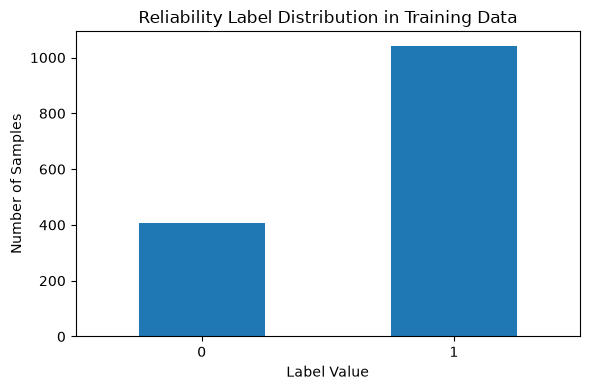

In [11]:
for role, normalized_column in NORMALIZED_LABEL_COLUMNS.items():
    counts = (
        train_df[normalized_column]
        .value_counts(dropna=False)
        .sort_index()
    )

    plt.figure(figsize=(6, 4))
    counts.plot(kind="bar")
    plt.title(f"{role.title()} Label Distribution in Training Data")
    plt.xlabel("Label Value")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 6. Joint Faithfulness–Relevancy analysis

In [12]:
faith_col = NORMALIZED_LABEL_COLUMNS.get("faithfulness")
relev_col = NORMALIZED_LABEL_COLUMNS.get("relevancy")
reliability_col = NORMALIZED_LABEL_COLUMNS.get("reliability")

if faith_col and relev_col:
    joint_counts = pd.crosstab(
        train_df[faith_col],
        train_df[relev_col],
        margins=True,
        dropna=False,
    )

    joint_ratios = pd.crosstab(
        train_df[faith_col],
        train_df[relev_col],
        normalize="all",
        dropna=False,
    )

    print("Joint counts:")
    display(joint_counts)

    print("Joint ratios:")
    display(joint_ratios)
else:
    print(
        "Faithfulness and/or Relevancy columns were not detected. "
        "Edit MANUAL_COLUMNS and rerun the notebook."
    )


Joint counts:


__relevancy_binary,0,1,All
__faithfulness_binary,,,
0,166,225,391
1,17,1042,1059
All,183,1267,1450


Joint ratios:


__relevancy_binary,0,1
__faithfulness_binary,,
0,0.114483,0.155172
1,0.011724,0.718621


In [13]:
reliability_mismatch_report = pd.DataFrame()

if faith_col and relev_col:
    valid_mask = (
        train_df[faith_col].notna()
        & train_df[relev_col].notna()
    )

    train_df.loc[valid_mask, "__expected_reliability"] = (
        train_df.loc[valid_mask, faith_col].astype(int)
        & train_df.loc[valid_mask, relev_col].astype(int)
    )

    train_df["__expected_reliability"] = (
        train_df["__expected_reliability"].astype("Int64")
    )

    if reliability_col:
        comparison_mask = (
            valid_mask
            & train_df[reliability_col].notna()
        )

        mismatch_mask = (
            comparison_mask
            & (
                train_df["__expected_reliability"]
                != train_df[reliability_col]
            )
        )

        print(
            "Reliability label mismatches:",
            int(mismatch_mask.sum())
        )

        report_columns = [
            column for column in [
                SELECTED_COLUMNS.get("identifier"),
                SELECTED_COLUMNS.get("faithfulness"),
                SELECTED_COLUMNS.get("relevancy"),
                SELECTED_COLUMNS.get("reliability"),
                faith_col,
                relev_col,
                reliability_col,
                "__expected_reliability",
            ]
            if column is not None and column in train_df.columns
        ]

        reliability_mismatch_report = train_df.loc[
            mismatch_mask,
            report_columns,
        ].copy()

        display(reliability_mismatch_report.head(20))

        reliability_mismatch_report.to_csv(
            RESULTS_DIR / "reliability_label_mismatches.csv",
            index=False,
        )
    else:
        print(
            "No explicit Reliability column was detected. "
            "The expected joint Reliability label was calculated internally."
        )


Reliability label mismatches: 0


,binary_faithfulness,binary_relevancy,joint_label,__faithfulness_binary,__relevancy_binary,__reliability_binary,__expected_reliability


## 7. Text-length analysis

In [14]:
TEXT_ROLES = ["question", "answer", "context"]
text_length_records = []

for split_name, df in datasets.items():
    for role in TEXT_ROLES:
        column = SELECTED_COLUMNS.get(role)

        if column is None or column not in df.columns:
            continue

        # For the context role, always use the combined all-chunks version
        # so that text-length analysis reflects the full retrieved context.
        if role == "context":
            text = build_combined_context(df)
        else:
            text = df[column].fillna("").astype(str)

        char_length = text.str.len()
        whitespace_token_length = text.str.split().str.len()

        text_length_records.append({
            "split": split_name,
            "role": role,
            "column": column,
            "mean_characters": float(char_length.mean()),
            "median_characters": float(char_length.median()),
            "p95_characters": float(char_length.quantile(0.95)),
            "p99_characters": float(char_length.quantile(0.99)),
            "max_characters": int(char_length.max()),
            "mean_whitespace_tokens": float(whitespace_token_length.mean()),
            "median_whitespace_tokens": float(whitespace_token_length.median()),
            "p95_whitespace_tokens": float(
                whitespace_token_length.quantile(0.95)
            ),
            "max_whitespace_tokens": int(whitespace_token_length.max()),
        })

text_length_summary = pd.DataFrame(text_length_records)
display(text_length_summary)

text_length_summary.to_csv(
    RESULTS_DIR / "text_length_summary.csv",
    index=False,
)


,split,role,column,mean_characters,median_characters,p95_characters,p99_characters,max_characters,mean_whitespace_tokens,median_whitespace_tokens,p95_whitespace_tokens,max_whitespace_tokens
0,train,question,question,69.740690,57.5,160.10,242.51,653,10.780000,9.0,25.00,92
1,train,answer,answer,425.985517,415.5,603.00,800.10,1124,60.521379,59.0,87.00,167
2,train,context,chunk_1,5236.131724,5446.5,8591.15,9289.71,10191,818.266207,856.5,1309.55,1595
3,validation,question,question,72.075862,61.5,158.20,218.43,329,11.148276,10.0,25.00,55
4,validation,answer,answer,424.331034,423.0,601.75,692.28,905,60.200000,59.0,86.10,130
5,validation,context,chunk_1,5477.003448,5730.5,8937.40,9325.10,9495,850.500000,891.5,1360.00,1483
6,test,question,question,73.903448,60.5,180.85,288.22,418,11.386207,9.0,29.55,64
7,test,answer,answer,425.803448,415.0,615.25,853.44,976,60.555172,58.0,89.55,146
8,test,context,chunk_1,5580.165517,6061.0,8679.75,9150.28,9629,873.500000,961.0,1296.65,1421


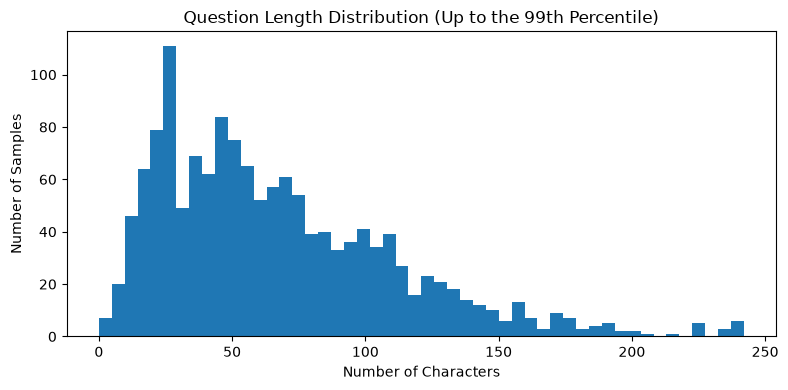

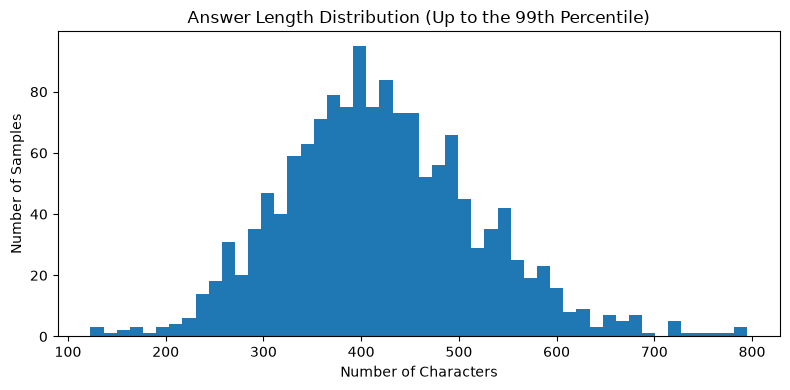

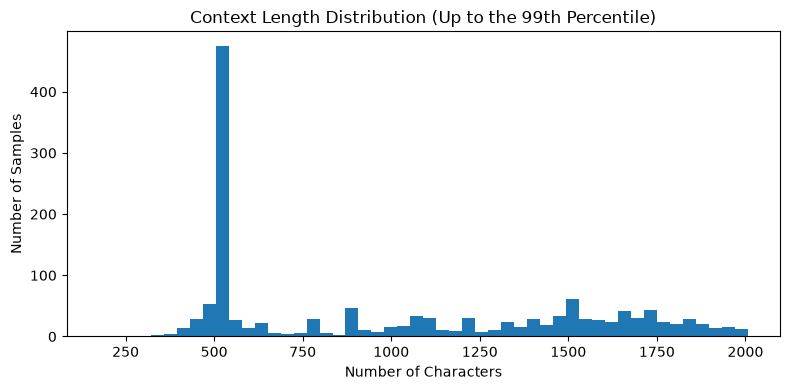

In [15]:
for role in TEXT_ROLES:
    column = SELECTED_COLUMNS.get(role)

    if column is None or column not in train_df.columns:
        continue

    lengths = train_df[column].fillna("").astype(str).str.len()
    upper_limit = lengths.quantile(0.99)
    filtered_lengths = lengths[lengths <= upper_limit]

    plt.figure(figsize=(8, 4))
    plt.hist(filtered_lengths, bins=50)
    plt.title(
        f"{role.title()} Length Distribution "
        "(Up to the 99th Percentile)"
    )
    plt.xlabel("Number of Characters")
    plt.ylabel("Number of Samples")
    plt.tight_layout()
    plt.show()


## 8. Check overlap between train, validation, and test

In [16]:
CONTEXT_COL = SELECTED_COLUMNS.get("context")

if CONTEXT_COL:
    datasets_with_context = {}
    for split_name, df in datasets.items():
        df_copy = df.copy()
        df_copy["__combined_context"] = build_combined_context(df)
        datasets_with_context[split_name] = df_copy
else:
    datasets_with_context = datasets

signature_columns = [
    SELECTED_COLUMNS.get("question"),
    SELECTED_COLUMNS.get("answer"),
    # use the derived combined-context column instead of the raw chunk column
    "__combined_context" if CONTEXT_COL else None,
]

signature_columns = [
    column
    for column in signature_columns
    if column is not None
    and all(column in df.columns for df in datasets_with_context.values())
]

print("Columns used for overlap checking:", signature_columns)


def create_row_signatures(df: pd.DataFrame, columns) -> set:
    if not columns:
        return set()

    normalized = df[columns].fillna("").astype(str).copy()

    for column in columns:
        normalized[column] = (
            normalized[column]
            .str.strip()
            .str.replace(r"\s+", " ", regex=True)
        )

    hashes = pd.util.hash_pandas_object(
        normalized,
        index=False,
    )

    return set(hashes.tolist())


if signature_columns:
    split_signatures = {
        split_name: create_row_signatures(df, signature_columns)
        for split_name, df in datasets_with_context.items()
    }

    split_names = list(split_signatures)
    overlap_records = []

    for first_index, first_split in enumerate(split_names):
        for second_split in split_names[first_index + 1:]:
            overlap = (
                split_signatures[first_split]
                & split_signatures[second_split]
            )

            overlap_records.append({
                "first_split": first_split,
                "second_split": second_split,
                "overlap_count": len(overlap),
            })

    overlap_summary = pd.DataFrame(overlap_records)
    display(overlap_summary)

    overlap_summary.to_csv(
        RESULTS_DIR / "cross_split_overlap.csv",
        index=False,
    )
else:
    print(
        "No suitable text columns were detected for overlap checking. "
        "Edit MANUAL_COLUMNS and rerun."
    )


Columns used for overlap checking: ['question', 'answer', '__combined_context']


,first_split,second_split,overlap_count
0,train,validation,0
1,train,test,0
2,validation,test,0


## 9. Inspect representative error cases

In [17]:
inspection_columns = [
    SELECTED_COLUMNS.get("identifier"),
    SELECTED_COLUMNS.get("question"),
    SELECTED_COLUMNS.get("answer"),
    SELECTED_COLUMNS.get("context"),
    SELECTED_COLUMNS.get("faithfulness"),
    SELECTED_COLUMNS.get("relevancy"),
    SELECTED_COLUMNS.get("reliability"),
]

inspection_columns = [
    column
    for column in inspection_columns
    if column is not None and column in train_df.columns
]

print("Inspection columns:", inspection_columns)


Inspection columns: ['question', 'answer', 'chunk_1', 'binary_faithfulness', 'binary_relevancy', 'joint_label']


In [18]:
def display_random_examples(
    df: pd.DataFrame,
    mask: pd.Series,
    title: str,
    columns,
    n: int = 5,
):
    subset = df.loc[mask, columns]

    print(f"{title}: {len(subset):,} samples")

    if subset.empty:
        return

    display(
        subset.sample(
            n=min(n, len(subset)),
            random_state=RANDOM_STATE,
        )
    )


if faith_col:
    display_random_examples(
        train_df,
        train_df[faith_col] == 0,
        "Unfaithful examples",
        inspection_columns,
    )

if relev_col:
    display_random_examples(
        train_df,
        train_df[relev_col] == 0,
        "Irrelevant examples",
        inspection_columns,
    )

if faith_col and relev_col:
    display_random_examples(
        train_df,
        (train_df[faith_col] == 0)
        & (train_df[relev_col] == 1),
        "Relevant but unfaithful examples",
        inspection_columns,
    )

    display_random_examples(
        train_df,
        (train_df[faith_col] == 1)
        & (train_df[relev_col] == 0),
        "Faithful but irrelevant examples",
        inspection_columns,
    )


Unfaithful examples: 391 samples


,question,answer,chunk_1,binary_faithfulness,binary_relevancy,joint_label
127,"[NAME] [NAME], подскажите пожалуйста, когда мне зачислят кэшбэк за покупку от [NUMBER] рублей ?","Кэшбэк за покупку от [NUMBER]₽ может быть начислен в рамках двух программ: \n1. **Акция «Кэшбэк [NUMBER]₽ за покупки»** (Document 6): \n - Если вы участвовали во второй волне (покупки с **[DATE] по [DATE]**), вознаграждение должно было быть зачислено **до [DATE]**. \n - Проверьте статус в...","# Программа лояльности для клиентов (категории и барабан): описание и ежемесячные изменения\n## 5. FAQ для сотрудников\n| Кэшбэк начислим за весь день 5 числа. | \n| |\n| --- |\n| 34. Если клиент совершил покупку [DATE], а подтверждение было [DATE][DATE], как начислим кэшбэк: за май или за июнь...",False,False,0_0
226,"Подскажите, пожалуйста, у меня какие-то ограничения по переводам на 24:00, долго это продлится?","В мобильном приложении Альфа-Банка дневные лимиты на переводы обновляются ежедневно и сбрасываются в 24:00. Если вы установили временный лимит (например, через «Мой контроль» — «Сегодня на вечер»), он будет действовать до конца дня (до следующего дня). Для проверки текущих лимитов откройте разде...",# Просмотр лимитов в приложении Альфа-Банка\n## 6. Редизайн (с версии iOS 14.8 и Android 12.28)\n| | | |\n| --- | --- | --- |\n| 1. Точки входа: | | |\n| * Зайдите в Платежи и переводы Лимиты | * Зайдите в экрана счёта Посмотреть лимиты | * Зайдите в профиль Лимиты |\n| | | |\n| 2. Вы можете пос...,False,False,0_0
198,"Здравствуйте, 18 декабря была получена карта впервые по ссылке из приложения магнит , за получение карты должны Быть начислены [NUMBER] бонусов. Подскажите банк подтвердил выполнение условий?","Чтобы проверить статус выполнения условий: \n1) Откройте раздел «Деньги вам и друзьям» в приложении — там отображается текущий статус рекомендации. \n2) Если статус «Новая», подождите: данные о покупке карты добавляются в историю рекомендаций в течение **2–3 календарных дней**, в редких случая...",Название статьи: Инструкция по работе с реферальной программой «Деньги вам и друзьям»\n\n\nСсылка: [URL]\n\n\nСодержание: # Инструкция по работе с реферальной программой «Деньги вам и друзьям»\n## 7. Как проверить уровень вознаграждения за дебетовую карту у клиента\nвознаграждение фиксировано на...,False,False,0_0
1115,"Здравствуйте, у меня кэшбэк 7% делевери доставка, я заказала продукты, через магазины досьавки делевери, почему у меня кэш прошел как прочие расходы всего 1%?","С 1 января 2025 года повышенный кэшбэк (7%) на Delivery, Яндекс.Еду и Яндекс.Лавку больше не начисляется, если у вас выбрана категория «хх% на все покупки», «2% через Alfa Pay» или «2% по Альфа-Стикеру». Вместо этого действует стандартный кэшбэк 1% (или 0,5% для некоторых клиентов) по категории ...","# Программа лояльности для клиентов (категории и барабан): описание и ежемесячные изменения\n## 2. Ежемесячные изменения\n--- 18. Некоторые клиенты смогут выбрать категорию «По Альфа-Стикеру» со ставкой кэшбэка 2%. У клиентов, которые получат возможность выбрать данное предложение, покажем вмест...",False,True,1_0
1335,Хочу муж хочет перевести пенсию в ваш банк? Действует ли акция [NUMBER] за перевод пенсии?,Акция «[NUMBER] Альфа-Баллов за перевод пенсии» завершилась [DATE][DATE] Сейчас действует новая акция с бонусом до [NUMBER] Альфа-Баллов — подробности можно уточнить в статье [Бонус до [NUMBER] Альфа-Баллов за перевод пенсии](/[NUMBER]). Если ваш муж начал перевод пенсии в рамках старой акции (д...,"Название статьи: Акция «Бонус [NUMBER] Альфа-Баллов за перевод пенсии. Для всех каналов»\n\n\nСсылка: [URL]\n\n\nСодержание: # Акция «Бонус [NUMBER] Альфа-Баллов за перевод пенсии. Для всех каналов»\n## Описание\n### Описание\nКлиенты, которые\nпереведут пенсию в Альфа-Банк и сделают покупку на ...",False,False,0_0


Irrelevant examples: 183 samples


,question,answer,chunk_1,binary_faithfulness,binary_relevancy,joint_label
177,Подскажите можно оформить 2 кредитные карты ?,"Да, Вы можете оформить несколько кредитных карт Альфа-Банка. Однако есть условия: 1) в течение одного дня можно подать заявку только на одну карту (через любой канал); 2) к одному счёту можно выпустить не более 4 карт. Для второй карты необходимо проверить наличие предодобренного предложения (ес...",Название статьи: Кредитная карта «30 дней без %» с [DATE]\n\n\nСсылка: [URL]\n\n\nСодержание: # Кредитная карта «30 дней без %» с [DATE]\n## Оформление\n| |\n| --- |\n| 4. В Альфа-Онлайн: |\n| [Заказ предодобренной кредитной карты в Альфа-Онлайн]([URL] ****Важные моменты:**** * Клиент может офор...,False,False,0_0
313,"У меня в разделе выгода горит сердечко ,хотя я его уже посмотрела","В разделе «Выгода» уведомления могут оставаться после просмотра. Чтобы удалить конкретное сообщение: откройте его долгое нажатием → выберите «Удалить». Для очистки всех уведомлений: зайдите в «Уведомления» → нажмите «Ещё» → «Выбрать всё» → «Удалить». Если проблема сохраняется, попробуйте обновит...","# Подписки на услугу Уведомления об операциях в приложении Альфа-Банка\n## 1. Как попасть на экран управления Уведомлениями об операциях\nДля\nподключения, отключения или изменения услуги Уведомления об операциях необходимо перейти на экран\nуправления Уведомлениями об операциях.\nПерейти можно ...",False,False,0_0
1121,"Здравствуйте, как начисляются баллы за отзыв?","За отзыв об Альфа-Банке с оценкой 4 или 5 на платформах (Сравни.ру, Отзовик, Банки.ру, Яндекс Карты) начисляется вознаграждение: [NUMBER], [NUMBER] или [NUMBER] рублей в зависимости от периода. Сумма выплачивается на рублёвый счёт клиента в течение 2 недель после зачёта отзыва модераторами. Балл...",# Деньги за отзыв об Альфа-Банке\n## Условия участия\n| |\n| --- |\n| Как получить вознаграждение за отзыв на Сравни.ру: |\n| С [DATE] акцию возобновляем. Ранее платили за отзывы на этой площадке до [DATE]. 1. Войдите или зарегистрируйтесь по номеру телефона на Сравни.ру. Чтобы мы могли зачислит...,False,False,0_0
836,Чем отличается Перевод между картами и Перевод клиенту банка?,"Перевод между картами Альфа-Банка — это перевод внутри банка (по номеру телефона, email или реквизитам) между счетами клиентов Альфа-Банка. Перевод клиенту банка через СБП — это перевод между разными банками по номеру телефона. Основные различия: 1) Переводы между картами Альфа-Банка не требуют ...","# СБП. Настройка параметров перевода\n## 1. Описание услуги\nСистема быстрых платежей (СБП) — услуга, которая позволяет клиентам Альфа-Банка переводить деньги по номеру телефона другим физлицам, у которых открыт счёт в банке-участнике СБП.\nЧтобы перевод прошёл — банк-получатель должен быть подк...",False,False,0_0
1096,"Здравствуйте! Уточните, пожалуйста, почему мне не начислен кэшбэк за покупку в Дикси доставка [DATE][DATE]?","Кэшбэк за покупку в Дикси Доставка 19.10 должен начислиться 10 числа следующего месяца, так как эта категория входит в партнёрские предложения с кэшбэком 16%. Если кэшбэк не начислился, проверьте: 1) не была ли операция отменена, 2) не оплачивали ли вы через QR/SBP, 3) не относится ли эта покупк...","# Программа лояльности для клиентов (категории и барабан): описание и ежемесячные изменения\n## 5. FAQ для сотрудников\n| Проверь поставщика по ИНН и расчётному счёту получателя на наличие его в [таблице ГИС ЖКХ]([URL] * Если нашёл поставщика, то операцию учтём вручную. Из-за того, что операция ...",False,False,0_0


Relevant but unfaithful examples: 225 samples


,question,answer,chunk_1,binary_faithfulness,binary_relevancy,joint_label
174,Оставлял заявку на КК. Не могу забрать в ДО. Можете поменять способ получения на доставку курьером ?,"Вы можете изменить способ получения карты на курьерскую доставку через приложение Альфа-Банка: откройте виджет доставки на главном экране или в разделе «Мои продукты», затем выберите новый адрес и время встречи. Если заявка уже отправлена и статус изменился (например, карта готова к выдаче), пот...",Название статьи: Виджет курьерской доставки в приложении Альфа-Банка\n\n\nСсылка: [URL]\n\n\nСодержание: # Виджет курьерской доставки в приложении Альфа-Банка\n## 2. Управление доставкой\n**1. Пользователь может изменять:** \n* Адрес\n* Дату и время доставки\n* Комментарий\n* Номер телефона \n...,False,True,1_0
1165,Здравствуйте. У меня есть комиссия за переводы с одной моей карты Альфа банка на другую карту Альфа банка?,"Переводы между своими картами Альфа-Банка бесплатны, если сумма не превышает лимиты: до [NUMBER] ₽ в месяц по номеру карты или до 30 млн ₽ в месяц по номеру телефона. Комиссия не взимается, если сумма перевода вписывается в эти рамки.",# Альфа-Счёт в приложении Альфа-Банка\n## 4. Пополнение Альфа-Счёта с карты другого банка\nПополнение накопительного Альфа-Счёта с карты другого банка доступно с версии приложения iOS 12.4 и Android 11.39. \nТарифы и лимиты идентичны переводам с карты другого банка на карту Альфа-Банка. Общие т...,False,True,1_0
834,"Здравствуйте, нужно перевыпустить карту, в связи с бракосочетанием",Для перевыпуска карты из-за изменения фамилии: 1) Откройте меню карты в приложении и выберите «Заменить карту». 2) Укажите причину перевыпуска (смена имени). 3) Выберите тип новой карты (цифровая или пластиковая). 4) Подтвердите заявку кодом из SMS или пуш-уведомления. После перевыпуска старый н...,"# Работа с картами в приложении Альфа-Банка\n## 10. Перевыпуск карты\n| |\n| --- |\n| Что видит клиент при попытке перевыпуска: |\n| | | | | --- | --- | | 1. Клиент заходит в меню карты и нажимает «Заменить карту». | 2. Если карта дебетовая, перенаправим клиента на витрину карт для выпуска любой...",False,True,1_0
1322,"Здравствуйте , мне нужно перевести свои деньги на другой банк","Чтобы перевести деньги на счёт в другом банке через мобильное приложение Альфа-Банка: 1) Откройте раздел «Счета и вклады», выберите нужный счёт; 2) Перейдите в «Платежи» → «Между счетами»; 3) В списке «Со своего счёта в другом банке» выберите банк получателя или нажмите «Выбрать банк»; 4) Укажит...",Название статьи: Переводы по номеру телефона в приложении Альфа-Банка\n\n\nСсылка: [URL]\n\n\nСодержание: # Переводы по номеру телефона в приложении Альфа-Банка\n## 6. СБП. Запрос на пополнение со своего счёта в другом банке (me2me pull)\n**Описание работы сервиса**\nВходящие запросы с подтвержд...,False,True,1_0
983,"работает ли кешбек 30% на продукты, несколько раз","Кэшбэк 30% на продукты не предусмотрен. В рамках программы лояльности Альфа-Банка категория «Продукты» может иметь кэшбэк 3% (а не 30%). Кэшбэк 30% доступен на другие категории (например, техника, такси, зоотовары), но не на продукты. Вы можете выбрать 3 категории с кэшбэком до 30% каждый месяц,...",# Программа лояльности для клиентов (категории и барабан): описание и ежемесячные изменения\n## 2. Ежемесячные изменения\nсуперкэшбэка. Ещё у вас будут скидки сразу в 3 сервисах Яндекса. Выбирать сервисы не нужно — пользуйтесь всеми сразу.* *В некоторых категориях процент может меняться. Чтобы о...,False,True,1_0


Faithful but irrelevant examples: 17 samples


,question,answer,chunk_1,binary_faithfulness,binary_relevancy,joint_label
501,условия приглашения друга на кредитку,"Чтобы пригласить друга на кредитку по программе «Деньги вам и друзьям», он должен: 1) оформить заявку по вашей ссылке, 2) в течение 3 месяцев получить карту и совершить покупку, 3) (если оформляет Alfa Only) обеспечить среднемесячный остаток [NUMBER] ₽ со второго месяца. Вознаграждение (размер з...","# Программа «Деньги вам и друзьям» по дебетовым картам\n## 4. Какие условия надо выполнить\n2. Условия, которые должен выполнить приглашённый друг, чтобы он и рекомендатель получили вознаграждение за рекомендацию: \n* Оформить заявку на рекомендованную дебетовую карту или стикер по ссылке реком...",True,False,0_1
572,"Здравствуйте, подскажите пожалуйста, кэшбэк за друга, ему пришёл неделю назад, а мне так и нет)","Выплата вознаграждения за друга обычно производится в течение 5-10 дней после выполнения всех условий программы, но в редких случаях может занять до конца следующего месяца. Проверьте, что друг выполнил все условия (активировал карту и совершил покупку по ней), и подождите ещё несколько дней. Ст...",# Программа «Деньги вам и друзьям» по дебетовым картам\n## 5. Срок выплаты вознаграждения рекомендателю и другу\n* Клиент \nна Цифровом тарифе (не присоединился к ДКБО) \nПроверить выплату рекомендатель и друг могут в разделе «Деньги вам и друзьям» в приложении Альфа-Банка или в Альфа-Онлайн. ...,True,False,0_1
717,"Мне недавно через поддержку отключали все пуш-оповещения бесполезные, но они снова начали поступать, в настройках так же они отключены . почему так происходит?","Возможные причины повторного поступления пуш-уведомлений: 1) На iOS пуши могут не работать из-за политики Apple , но приложение продолжает функционировать. 2) С [DATE] пуши на iOS не отправляются, но вы можете выбрать смс-уведомления . 3) Пуши могут заменять смс, если выбран соответствующий тари...","# Пуш в приложении Альфа-Банка\n## 1. Настройка получения пуш и смс по услуге Уведомления об операциях\nНедоставленные пуш сохраняем в разделе «Колокольчик» в приложении Альфа-Банка. Если клиент не может найти уведомления в колокольчике, вероятнее всего у клиента отключены пуш в настройках прило...",True,False,0_1
1222,"Здравствуйте, два дня подряд обращался в банк по поводу списания денег за альфа-чек,услугу я не подключал, а денги списали, сегодня пришёл ответ, что деньги вернуть нельзя, как так получается?","Если Вы не подключали услугу Альфа-Чек, но с карты списались деньги, Вы можете оспорить комиссию через мобильное приложение. Для этого откройте историю операций, найдите соответствующую операцию и нажмите «Оспорить операцию». В чате выберите причину — «Не понимаю, за что списались деньги». Если ...","# Подача обращений из «Истории операций» в приложении Альфа-Банка\n## 2. Процесс оспаривания покупок\n**Ограничения по операциям:** \n1. Оспаривать можно операции за последние 12 месяцев\n2. Холды не оспариваются\n3. В одном обращении — до 5 операций\n4. Оспаривание доступно с iOS 11.25, Androi...",True,False,0_1
899,Как качать кэшбэк октября?,"Чтобы получить кэшбэк за октябрь, с [DATE][DATE] года в мобильном приложении Альфа-Банка откройте раздел «Кэшбэк и сервисы» на главном экране. Выберите категории кэшбэка, которые вам интересны, и покрутите барабан суперкэшбэка (если доступно). Кэшбэк за октябрь будет[DATE][DATE][DATE] года. Обра...",# Программы лояльности в приложении Альфа-Банка — виджет единой лояльности «Кэшбэк и сервисы»\n## 8. Старый виджет кэшбэка\nПоказываем в старых версиях приложения Альфа-Банка. \n| | |\n| --- | --- |\n| 1. На главном экране нажмите на «Кэшбэк и привилегии»: | 2. Перейдите в раздел информации о к...,True,False,0_1


## 10. Read existing project quality reports

In [19]:
quality_report_path = PROCESSED_DIR / "data_quality_report.json"
existing_split_summary_path = PROCESSED_DIR / "split_summary.csv"

if quality_report_path.exists():
    with quality_report_path.open("r", encoding="utf-8") as file:
        quality_report = json.load(file)

    print("Existing data quality report:")
    display(quality_report)
else:
    print("No data_quality_report.json file was found.")

if existing_split_summary_path.exists():
    print("\nExisting split summary:")
    existing_split_summary = pd.read_csv(
        existing_split_summary_path,
        low_memory=False,
    )
    display(existing_split_summary)
else:
    print("No split_summary.csv file was found.")


Existing data quality report:


{'input_file': 'C:\\Users\\kosti\\Documents\\assessing-reliability-of-responses-in-rag\\data.csv',
 'seed': 42,
 'initial_rows': 2245,
 'exact_duplicates_removed': 8,
 'conflicting_annotation_rows_quarantined': 8,
 'rows_without_substantive_question_quarantined': 199,
 'main_rows': 2030,
 'dialog_groups': 1940,
 'selected_validation_fold': 3,
 'selected_test_fold': 5,
 'split_optimization_score': 0.0026377344754786717,
 'split_counts': {'train': 1450, 'val': 290, 'test': 290},
 'group_leakage_detected': False,
 'notes': ['Different answers for the same full_dialog are retained.',
  'All rows sharing the same normalized full_dialog are assigned to one split.',
  'Rows without a substantive client request are quarantined rather than permanently discarded.',
  'Markers are not used as model inputs and are retained only as metadata/partial supervision.'],
 '中文说明': ['同一 full_dialog 下的不同回答会被保留。',
  '具有相同标准化 full_dialog 的所有行会被分配到同一个数据划分。',
  '缺少实质性客户请求的行会被隔离，而不是永久删除。',
  'markers 不作为模型输入，仅作为元


Existing split summary:


,split,rows,proportion,dialog_groups,relevancy_positive_rate,faithfulness_positive_rate,reliability_positive_rate,label_0_0,label_0_1,label_1_0,label_1_1,top_5_rows,top_8_rows
0,all,2030,1.000000,1940,0.873399,0.731527,0.719212,232,25,313,1460,1670,360
1,train,1450,0.714286,1385,0.873793,0.730345,0.718621,166,17,225,1042,1194,256
2,val,290,0.142857,277,0.872414,0.734483,0.720690,33,4,44,209,237,53
3,test,290,0.142857,278,0.872414,0.734483,0.720690,33,4,44,209,239,51


## 11. Export a compact JSON summary

In [20]:
eda_summary = {
    "selected_columns": SELECTED_COLUMNS,
    "split_sizes": {
        split_name: int(len(df))
        for split_name, df in datasets.items()
    },
    "exact_duplicate_rows": {
        split_name: int(df.duplicated().sum())
        for split_name, df in datasets.items()
    },
    "label_columns_detected": list(NORMALIZED_LABEL_COLUMNS.keys()),
    "signature_columns": signature_columns,
}

# Document how the context field is handled since it spans multiple chunk columns.
context_col = SELECTED_COLUMNS.get("context")
if context_col is None:
    eda_summary["context_note"] = (
        "The processed dataset does not contain a retrieved-context column, "
        "so context-length analysis could not be performed."
    )
else:
    eda_summary["context_note"] = (
        f"The context is stored across multiple chunk columns "
        f"(chunk_1 … chunk_5; chunk_6–8 optional). "
        f"MANUAL_COLUMNS['context'] = '{context_col}' was used as the primary identifier. "
        f"The build_combined_context() helper concatenates all available chunks "
        f"for text-length analysis and cross-split overlap checking."
    )

if faith_col and relev_col:
    valid_joint = train_df[
        train_df[faith_col].notna()
        & train_df[relev_col].notna()
    ]

    eda_summary["train_joint_label_counts"] = {
        f"faithfulness_{int(faith)}_relevancy_{int(relevancy)}": int(count)
        for (faith, relevancy), count in (
            valid_joint
            .groupby([faith_col, relev_col])
            .size()
            .items()
        )
    }

if faith_col and relev_col and reliability_col:
    eda_summary["reliability_label_mismatch_count"] = int(
        len(reliability_mismatch_report)
    )

summary_path = RESULTS_DIR / "eda_summary.json"

with summary_path.open("w", encoding="utf-8") as file:
    json.dump(
        eda_summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Saved:", summary_path)
display(eda_summary)


Saved: /Users/chengyi/assessing-reliability-of-responses-in-rag/results/data_exploration/eda_summary.json


{'selected_columns': {'question': 'question',
  'answer': 'answer',
  'context': 'chunk_1',
  'faithfulness': 'binary_faithfulness',
  'relevancy': 'binary_relevancy',
  'reliability': 'joint_label',
  'identifier': None},
 'split_sizes': {'train': 1450, 'validation': 290, 'test': 290},
 'exact_duplicate_rows': {'train': 0, 'validation': 0, 'test': 0},
 'label_columns_detected': ['faithfulness', 'relevancy', 'reliability'],
 'signature_columns': ['question', 'answer', '__combined_context'],
 'context_note': "The context is stored across multiple chunk columns (chunk_1 … chunk_5; chunk_6–8 optional). MANUAL_COLUMNS['context'] = 'chunk_1' was used as the primary identifier. The build_combined_context() helper concatenates all available chunks for text-length analysis and cross-split overlap checking.",
 'train_joint_label_counts': {'faithfulness_0_relevancy_0': 166,
  'faithfulness_0_relevancy_1': 225,
  'faithfulness_1_relevancy_0': 17,
  'faithfulness_1_relevancy_1': 1042},
 'reliabili

## 12. Main findings

### Dataset structure

- **Train samples:** 1,450 (70.0%)
- **Validation samples:** 290 (14.1%)
- **Test samples:** 290 (14.1%)
- **Question column:** `question` (extracted from `full_dialog`)
- **Answer column:** `answer` (generated response)
- **Context column:** `chunk_1` (primary chunk; `chunk_2`–`chunk_5` also available; `chunk_6`–`chunk_8` optional for top-8 retrieval). `chunk_1` was selected as the primary identifier. The `build_combined_context()` helper concatenates all available chunks for text-length analysis and cross-split overlap checking.
- **Label columns:**
  - `binary_faithfulness` (faithful = 1, unfaithful = 0)
  - `binary_relevancy` (relevant = 1, irrelevant = 0)
  - `joint_label` (format: `{relevancy}_{faithfulness}`, e.g., "1_1" means reliable)

### Data quality

- **Missing-value issues:** `markers` column has 93–95% missing values (expected; used for partial supervision only). `chunk_6/7/8` have ~82% missing (top-5 retrieval config, these chunks are not retrieved).
- **Exact duplicates:** 0 (dataset is deduplicated)
- **Cross-split overlap:** 0 (perfect separation via StratifiedGroupKFold on `dialog_group_id`)
- **Reliability-label inconsistencies:** 0 (verified: `Reliability = Faithfulness AND Relevancy`)

### Label balance

| Label | Positive (1) | Negative (0) | Positive Ratio |
|-------|-------------|--------------|---------------|
| Faithfulness | 1,059 | 391 | 73.0% |
| Relevancy | 1,267 | 183 | 87.4% |
| Reliability | 1,042 | 408 | 71.9% |

**Joint label distribution (train):**

| faithfulness | relevancy | count | ratio | reliability |
|--------------|-----------|-------|-------|-------------|
| 0 | 0 | 166 | 11.4% | unreliable |
| 0 | 1 | 225 | 15.5% | unreliable |
| 1 | 0 | 17 | 1.2% | unreliable |
| 1 | 1 | 1,042 | 71.9% | reliable |

**Most common combination:** faithfulness=1, relevancy=1 (71.9% of samples)

### Text characteristics

| Field | Median Characters | Median Tokens | P95 Characters | Max Characters |
|-------|------------------|---------------|----------------|----------------|
| Question | 57.5 | 9 | 160 | 653 |
| Answer | 415.5 | 59 | 603 | 1,124 |
| Context (chunk_1) | 5,447 | 857 | 8,591 | 10,191 |

**Important observations:**
- Questions are short (median 9 tokens)
- Answers are moderate length (median 59 tokens)
- Retrieved context chunks are long (median 857 tokens) — typical for banking domain RAG
- Answer lengths are relatively consistent (P95=603 characters vs median=416)

### Implications for modeling

1. **Is class weighting needed?** Yes, but the approach depends on the model type:
   - Traditional classifiers (e.g., SVM, LogisticRegression): use `class_weight="balanced"` or `sample_weight`
   - Neural network classifiers: consider weighted cross-entropy or focal loss

2. **Report macro-F1 as the primary metric**, while also reporting per-class precision, recall, F1, and confusion matrix for detailed analysis.

3. **Compare EDA findings with existing TF-IDF baseline results** in `results/stage2_tfidf/` to identify which label is the weakest performer.

4. **Focus on the "relevant but unfaithful" subgroup** (225 samples, 15.5%), which is the largest minority failure class — these cases have good retrieval but suffer from hallucinations.

5. **Future models should leverage the full context**: question + answer + complete retrieved context (multiple chunks via `build_combined_context()`).
